## Visualize Cell Types (CT) by Cell Type Annotation Tool (CTann)

Here, we build the histogram below for **private** pancreas data out of GTEx.

![](images/goal_vis.png)

## Install and import libraries

In [49]:
%pip install requests pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load data

In [50]:
# Make sure the data folder is present
folder_path = 'data'
file_name = 'gtex-private-cell-instances.csv.gz' # note that this is private data and not commited in this repo

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created.")
else:
    print(f"Folder '{folder_path}' already exists.")

# Define the path to the file. 
file_path = f'{folder_path}/{file_name}'

Folder 'data' already exists.


## Preprocess data

In [51]:
dtype_dict = {
    'organ': 'str',
    'tool': 'category',
    'cell': 'str',
    'confidence_score': 'float32'
}

df = pd.read_csv(
  file_path, 
  compression='gzip',
  dtype=dtype_dict, 
  # usecols=dtype_dict.keys()
  )
df

,dataset,organ,tool,cell,cell_id,cell_label,match_type,confidence_score
0,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGCACGTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.747197
1,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGACCTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.862035
2,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGCGATA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.797622
3,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATGGTTAT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.857463
4,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATTGCGTA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.630241
...,...,...,...,...,...,...,...,...
48254,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTGGCAAGGTCCT-1-1LVAN,CL:0002064,pancreatic acinar cell,skos:exactMatch,1.000000
48255,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTATTTGGG-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,1.000000
48256,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTGCAATGC-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,0.833333
48257,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTTACGCAA-1-1LVAN,CL:0000057,fibroblast,skos:exactMatch,1.000000


In [52]:
df.columns

Index(['dataset', 'organ', 'tool', 'cell', 'cell_id', 'cell_label',
       'match_type', 'confidence_score'],
      dtype='object')

In [53]:
df['tool'] = df['tool'].astype('category')

df_filtered = df[df['tool'] != 'panhuman']
df_filtered['tool'] = df_filtered['tool'].cat.remove_unused_categories()
# df_filtered = df
df_filtered

,dataset,organ,tool,cell,cell_id,cell_label,match_type,confidence_score
0,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGCACGTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.747197
1,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGACCTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.862035
2,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGCGATA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.797622
3,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATGGTTAT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.857463
4,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATTGCGTA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.630241
...,...,...,...,...,...,...,...,...
48254,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTGGCAAGGTCCT-1-1LVAN,CL:0002064,pancreatic acinar cell,skos:exactMatch,1.000000
48255,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTATTTGGG-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,1.000000
48256,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTGCAATGC-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,0.833333
48257,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTTACGCAA-1-1LVAN,CL:0000057,fibroblast,skos:exactMatch,1.000000


In [54]:
# number of unique cell instances
print(f'The number of unique cell instances is {df_filtered["cell"].nunique()}.')

The number of unique cell instances is 16222.


## Visualize

In [55]:
sns.set_theme(rc={'figure.figsize': (16,8)})

plt.rcParams.update({'font.size': 14,  # Controls default text size
                     'axes.labelsize': 12,  # Controls axes label size
                     'xtick.labelsize': 10,  # Controls x-axis tick label size
                     'ytick.labelsize': 10,  # Controls y-axis tick label size
                     'legend.fontsize': 12})  # Controls legend font size

Text(0, 0.5, '# of Cells')

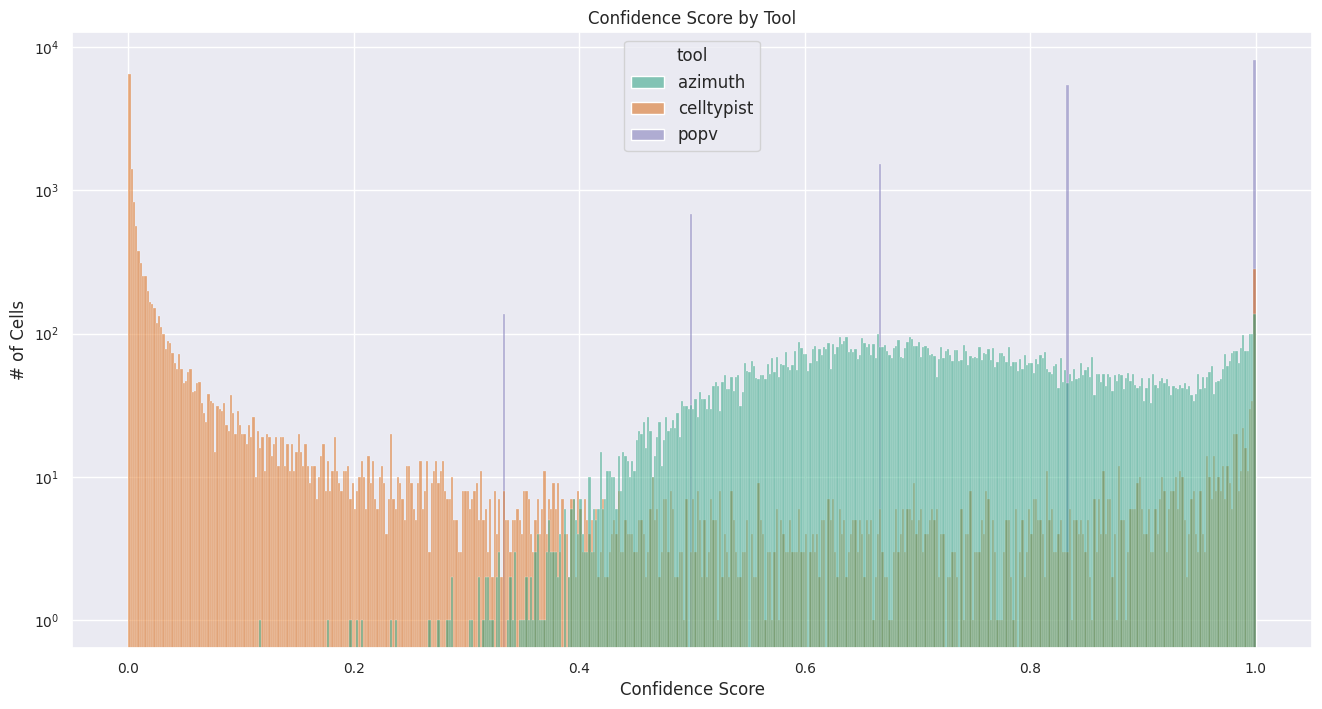

In [56]:
# make plot
g = sns.histplot(
  data=df_filtered, 
  x="confidence_score",
  binwidth=.002, 
  hue='tool',
  palette="Dark2"
  )

# Set the style to white
sns.set_style('white')

# adjust scales
plt.yscale('log')

# adjust labels++
plt.title('Confidence Score by Tool')
plt.xlabel('Confidence Score')
plt.ylabel('# of Cells')

## Build table

|                           	| Low confidence 	| High confidence 	|
|---------------------------	|----------------	|-----------------	|
| All  CTann tools agree    	| 5,938    	| 1,166     	|
| 2 CTann agree             	| 15,228    	| 8,354     	|
| All  CTann tools disagree 	| 815    	| 812     	|

**Note: High confidence level means the confidence score by the CTann tool is > .9.**

In [57]:
# unique cell instances
df_filtered['cell'].nunique()

16222

In [58]:
# add confidence
df_filtered['confidence_level'] = df_filtered['confidence_score'].apply(lambda s: 'high' if s > .9 else 'low')
df_filtered

,dataset,organ,tool,cell,cell_id,cell_label,match_type,confidence_score,confidence_level
0,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGCACGTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.747197,low
1,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGACCTT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.862035,low
2,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCAGGCGATA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.797622,low
3,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATGGTTAT-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.857463,low
4,GTEX-PRIVATE-1JKYN,UBERON:0001264,azimuth,AAACAGCCATTGCGTA-1-1JKYN,CL:0002064,pancreatic acinar cell,skos:exactMatch,0.630241,low
...,...,...,...,...,...,...,...,...,...
48254,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTGGCAAGGTCCT-1-1LVAN,CL:0002064,pancreatic acinar cell,skos:exactMatch,1.000000,high
48255,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTATTTGGG-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,1.000000,high
48256,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTGCAATGC-1-1LVAN,CL:0002079,pancreatic ductal cell,skos:exactMatch,0.833333,low
48257,GTEX-PRIVATE-1LVAN,UBERON:0001264,popv,TTTGTTGGTTACGCAA-1-1LVAN,CL:0000057,fibroblast,skos:exactMatch,1.000000,high


In [60]:
# identify cell_ids that have all 3 unique tool values
def get_cells_with_tools(n_tools:int):
  """Get number of cells where n tools assign the same CT

  Args:
      n_tools (int): number of tools
  """

  cell_ids_with_all_tools = (
      df_filtered.groupby('cell_id')['tool']
      .nunique()
      .loc[lambda x: x == n_tools]
      .index
  )

  # filter the original dataframe to only include rows with those cell_ids
  df_table = df_filtered[df_filtered['cell_id'].isin(cell_ids_with_all_tools)]

  # count unique cells for each confidence level
  low_confidence_cells = df_table[df_table['confidence_level']
                                    == 'low']['cell'].nunique()
  high_confidence_cells = df_table[df_table['confidence_level']
                                      == 'high']['cell'].nunique()

  print(
      f'Number of unique cells with {n_tools} tools and low confidence: {"{:,}".format(low_confidence_cells)}')
  print(
      f'Number of unique cells with {n_tools} tools and high confidence: {"{:,}".format(high_confidence_cells)}')
  print()

get_cells_with_tools(3)
get_cells_with_tools(2)
get_cells_with_tools(1)

Number of unique cells with 3 tools and low confidence: 5,938
Number of unique cells with 3 tools and high confidence: 1,166

Number of unique cells with 2 tools and low confidence: 15,228
Number of unique cells with 2 tools and high confidence: 8,354

Number of unique cells with 1 tools and low confidence: 815
Number of unique cells with 1 tools and high confidence: 812

